In [1]:
import yfinance as yf
df = yf.download('AAPL', start='2020-01-01'); df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.271538,72.331694,71.029915,71.282568,135480400
2020-01-03,71.568924,72.326889,71.345145,71.501549,146322800
2020-01-06,72.139221,72.177722,70.442821,70.693073,118387200
2020-01-07,71.799927,72.403889,71.580958,72.148828,108872000
2020-01-08,72.954926,73.255706,71.503960,71.503960,132079200


<Axes: title={'center': 'AAPL Close Price'}, xlabel='Date'>

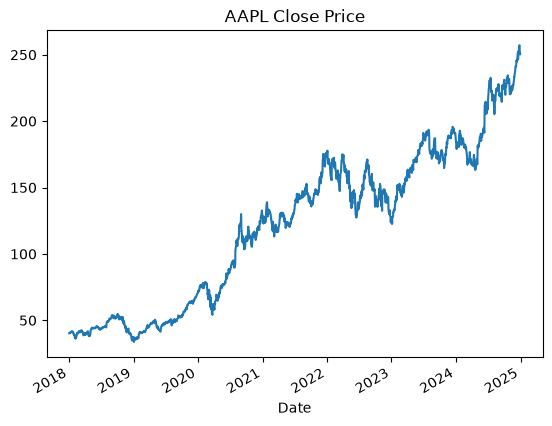

In [2]:
from data.load_data import load_universe
universe = load_universe(["AAPL", "MSFT", "JPM", "XOM", "SPY"])
universe["AAPL"].head()
universe["AAPL"]["Close"].plot(title="AAPL Close Price")

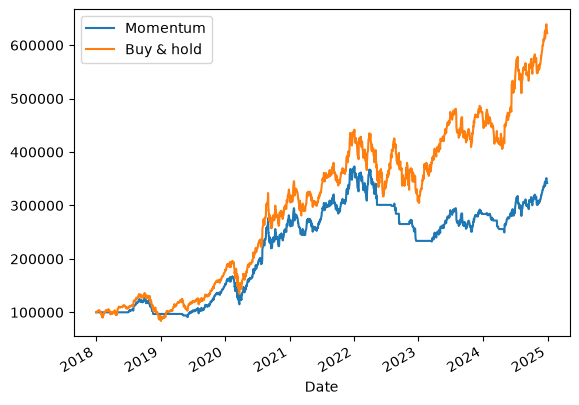

In [3]:
from data.load_data import load_universe          # use whatever yours is actually called
from strategies.momentum import momentum_signal
from engine.vectorized import run_backtest

data = load_universe(["AAPL"])
close = data["AAPL"]["Close"]

signal = momentum_signal(close, lookback=126)
result = run_backtest(close, signal)

buy_hold = 100_000 * (1 + close.pct_change().fillna(0)).cumprod()

ax = result["equity"].plot(label="Momentum")
buy_hold.plot(ax=ax, label="Buy & hold")
ax.legend();

<Axes: xlabel='Date'>

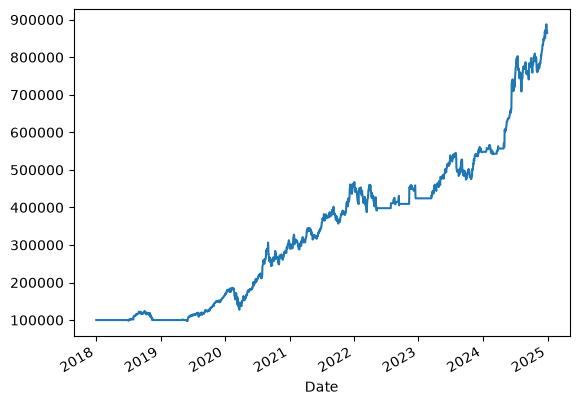

In [4]:
cheat = 100_000 * (1 + (signal * close.pct_change()).fillna(0)).cumprod()  # NO shift
cheat.plot(label="Cheating (no shift)")

this is what look-ahead bias looks like

In [5]:
from data.load_data import load_universe
from strategies.momentum import momentum_signal
from engine.vectorized import run_backtest

close = load_universe(["AAPL"])["AAPL"]["Close"]

for lb in [20, 60, 126, 252]:
    out = run_backtest(close, momentum_signal(close, lookback=lb))
    print(lb, round(out["equity"].iloc[-1]))

20 503121
60 321237
126 341998
252 308922


In [6]:
from strategies.mean_reversion import mean_reversion_signal

sig = mean_reversion_signal(close, window=20, threshold=0.05)
out = run_backtest(close, sig)

print("final equity:", round(out["equity"].iloc[-1]))
print("% of days invested:", round(sig.mean() * 100, 1))
print("number of trades:", int((sig.diff() == 1).sum()))

final equity: 113244
% of days invested: 18.9
number of trades: 23


In [7]:
for window in [10, 20, 50]:
    for thr in [0.02, 0.05, 0.08]:
        s = mean_reversion_signal(close, window, thr)
        o = run_backtest(close, s)
        print(window, thr, round(o["equity"].iloc[-1]), f"{s.mean():.0%} invested",
              int((s.diff() == 1).sum()), "trades")

10 0.02 112361 27% invested 63 trades
10 0.05 150765 11% invested 25 trades
10 0.08 121714 4% invested 8 trades
20 0.02 86860 29% invested 38 trades
20 0.05 113244 19% invested 23 trades
20 0.08 100007 10% invested 10 trades
50 0.02 201107 28% invested 35 trades
50 0.05 161890 21% invested 18 trades
50 0.08 142815 15% invested 10 trades
